# Segmentation clients et prédiction du churn (BankChurners)

Ce notebook reprend le pipeline de `train.py` :
1. Préparation des données
2. CAH sur les variables
3. ACP (PCA)
4. CAH sur les individus
5. Profilage des segments et croisement au churn
6. KNN — prédiction supervisée du churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    silhouette_score,
)

RANDOM_STATE = 42

## Étape 1 — Préparation

In [2]:
print("=" * 60)
print("ÉTAPE 1 — PRÉPARATION")
print("=" * 60)

df = pd.read_csv("BankChurners.csv")

# Vérification qualité des données : valeurs manquantes et doublons
missing = df.isna().sum()
missing = missing[missing > 0]
n_duplicated_rows = df.duplicated().sum()
n_duplicated_ids = df["CLIENTNUM"].duplicated().sum()

print(f"Dimensions brutes : {df.shape}")
if missing.empty:
    print("Valeurs manquantes : aucune")
else:
    print("Valeurs manquantes par colonne :")
    print(missing)
print(f"Lignes dupliquées : {n_duplicated_rows}")
print(f"CLIENTNUM dupliqués : {n_duplicated_ids}")

naive_bayes_cols = [c for c in df.columns if c.startswith("Naive_Bayes_")]
df = df.drop(columns=["CLIENTNUM"] + naive_bayes_cols, errors="ignore")
print(f"Dimensions après nettoyage : {df.shape}")

# Variables comportementales numériques utilisées pour la typologie
behavior_features = [
    "Customer_Age",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

# CAH réalisée sur la totalité du dataset (peut être plus lent que sur un échantillon,
# la complexité de la CAH étant O(n^2) à O(n^3) contrairement au K-Means)
df_sample = df.reset_index(drop=True)
print(f"Clients retenus pour la CAH : {df_sample.shape[0]} (dataset complet)")

X = df_sample[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=behavior_features)
print("-" * 60)

ÉTAPE 1 — PRÉPARATION
Dimensions brutes : (10127, 23)
Valeurs manquantes : aucune
Lignes dupliquées : 0
CLIENTNUM dupliqués : 0
Dimensions après nettoyage : (10127, 20)
Clients retenus pour la CAH : 10127 (dataset complet)
------------------------------------------------------------


## Étape 2 — CAH sur les variables (hors-d'œuvre)

ÉTAPE 2 — CAH SUR LES VARIABLES


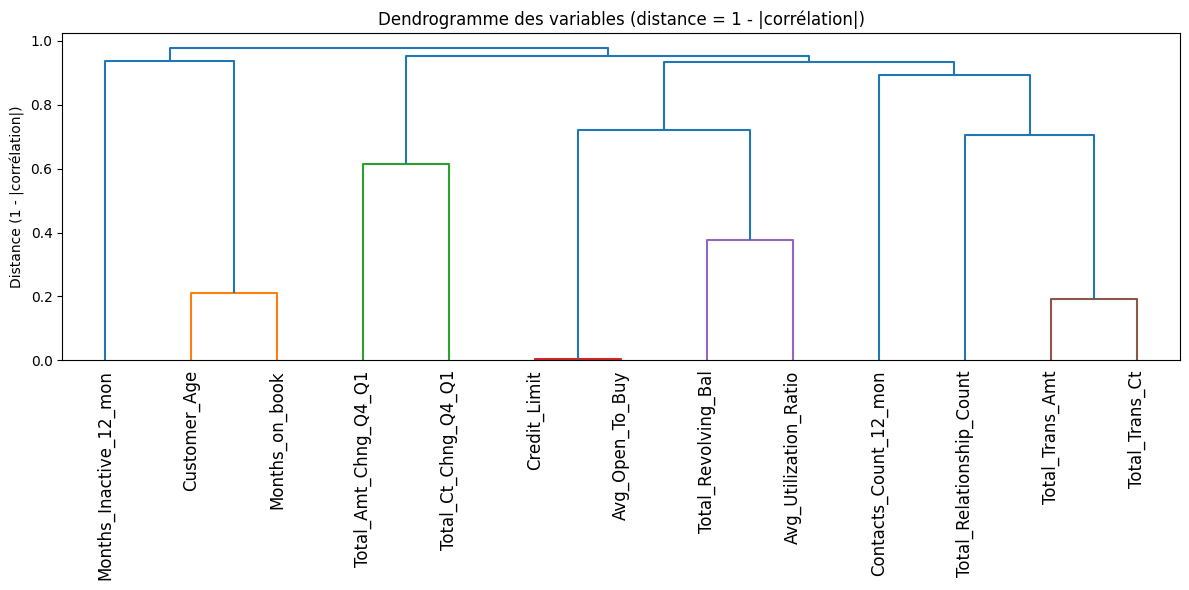

Dendrogramme des variables sauvegardé : dendrogramme_variables.png

Top 5 des paires de variables les plus corrélées (redondance) :
Credit_Limit         Avg_Open_To_Buy          0.995981
Total_Trans_Amt      Total_Trans_Ct           0.807192
Customer_Age         Months_on_book           0.788912
Total_Revolving_Bal  Avg_Utilization_Ratio    0.624022
Avg_Open_To_Buy      Avg_Utilization_Ratio    0.538808
dtype: float64


In [3]:
print("=" * 60)
print("ÉTAPE 2 — CAH SUR LES VARIABLES")
print("=" * 60)

corr = X_scaled_df.corr()
dist_vars = 1 - corr.abs()
condensed_vars = squareform(dist_vars.values, checks=False)
Z_vars = linkage(condensed_vars, method="average")

plt.figure(figsize=(12, 6))
dendrogram(Z_vars, labels=corr.columns.tolist(), leaf_rotation=90)
plt.title("Dendrogramme des variables (distance = 1 - |corrélation|)")
plt.ylabel("Distance (1 - |corrélation|)")
plt.tight_layout()
plt.savefig("dendrogramme_variables.png", dpi=150)
plt.show()
print("Dendrogramme des variables sauvegardé : dendrogramme_variables.png")

# Paires les plus corrélées (fusion immédiate attendue)
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("\nTop 5 des paires de variables les plus corrélées (redondance) :")
print(corr_pairs.head(5))

## Étape 3 — ACP (PCA)

In [4]:
print("=" * 60)
print("ÉTAPE 3 — ACP (PCA)")
print("=" * 60)

N_COMPONENTS = 4
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("Variance expliquée par composante :")
for i, v in enumerate(explained, start=1):
    print(f"  PC{i} : {v * 100:.1f}%")
print(f"Variance cumulée (4 axes) : {explained.sum() * 100:.1f}%")

loadings = pd.DataFrame(
    pca.components_.T,
    index=behavior_features,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
)
print("\nContributions des variables aux axes (loadings) :")
print(loadings.round(2))

ÉTAPE 3 — ACP (PCA)
Variance expliquée par composante :
  PC1 : 19.7%
  PC2 : 15.7%
  PC3 : 13.7%
  PC4 : 11.1%
Variance cumulée (4 axes) : 60.2%

Contributions des variables aux axes (loadings) :
                           PC1   PC2   PC3   PC4
Customer_Age             -0.03 -0.25  0.65  0.06
Months_on_book           -0.02 -0.25  0.65  0.06
Total_Relationship_Count -0.17 -0.24 -0.16  0.28
Months_Inactive_12_mon   -0.02 -0.09  0.08 -0.10
Contacts_Count_12_mon    -0.01 -0.20 -0.12 -0.05
Credit_Limit              0.54 -0.13 -0.01  0.27
Total_Revolving_Bal      -0.16  0.26  0.14  0.38
Avg_Open_To_Buy           0.56 -0.16 -0.03  0.24
Total_Amt_Chng_Q4_Q1     -0.01  0.14 -0.06  0.53
Total_Trans_Amt           0.30  0.50  0.20 -0.17
Total_Trans_Ct            0.23  0.52  0.19 -0.18
Total_Ct_Chng_Q4_Q1      -0.01  0.21  0.02  0.52
Avg_Utilization_Ratio    -0.45  0.28  0.11  0.16


## Étape 4 — CAH sur les individus (le cœur)

ÉTAPE 4 — CAH SUR LES INDIVIDUS (Ward, sur composantes PCA)


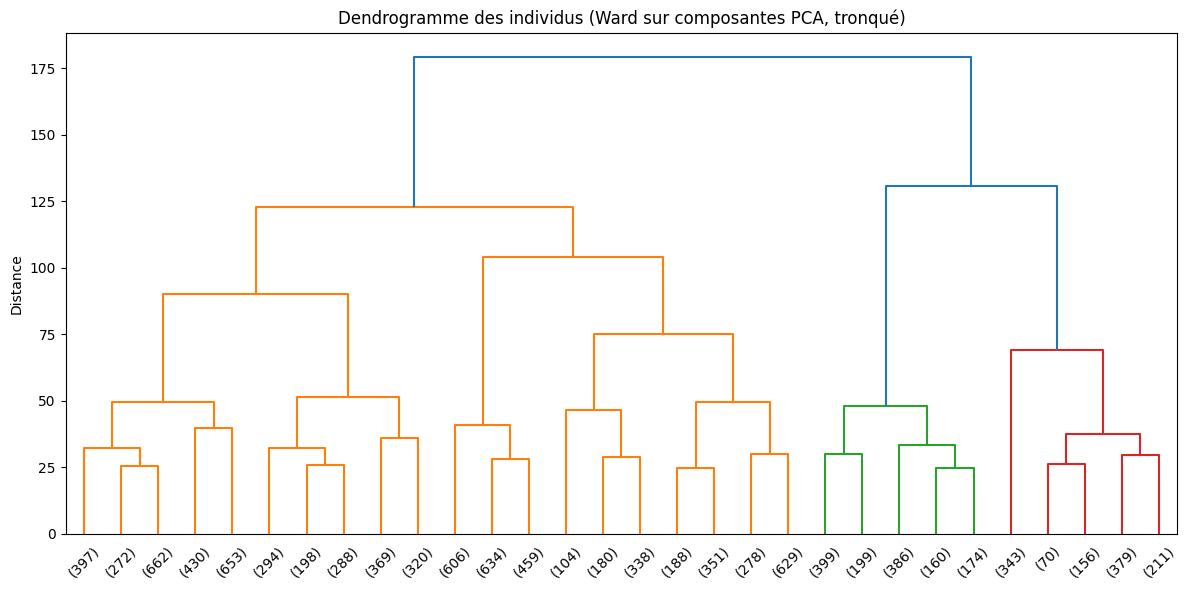

Dendrogramme des individus sauvegardé : dendrogramme_individus.png

Plus grand saut de distance détecté → k = 2 segments retenus


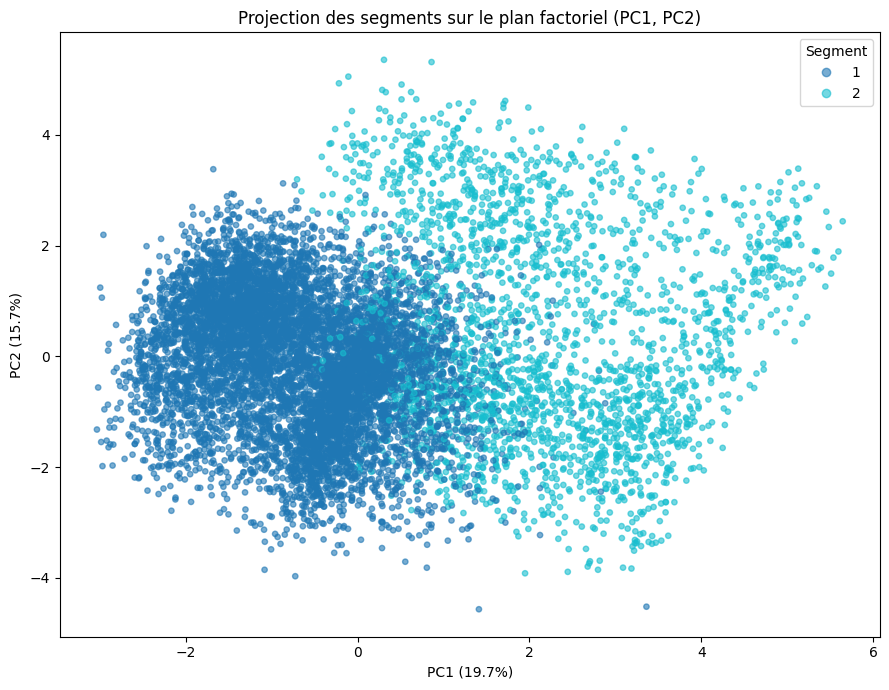

Projection des segments sauvegardée : plan_factoriel_segments.png


In [5]:
print("=" * 60)
print("ÉTAPE 4 — CAH SUR LES INDIVIDUS (Ward, sur composantes PCA)")
print("=" * 60)

Z_ind = linkage(X_pca, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z_ind, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Dendrogramme des individus (Ward sur composantes PCA, tronqué)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("dendrogramme_individus.png", dpi=150)
plt.show()
print("Dendrogramme des individus sauvegardé : dendrogramme_individus.png")

# Choix du nombre de clusters : plus grand saut de distance dans les dernières fusions
last_merges = Z_ind[-10:, 2]
jumps = np.diff(last_merges)
n_clusters = len(last_merges) - np.argmax(jumps) - 1
n_clusters = max(2, min(6, n_clusters))
print(f"\nPlus grand saut de distance détecté → k = {n_clusters} segments retenus")

df_sample["Segment"] = fcluster(Z_ind, t=n_clusters, criterion="maxclust")

# Validation visuelle : projection des clusters sur le plan factoriel PC1-PC2
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_sample["Segment"], cmap="tab10", alpha=0.6, s=15
)
plt.xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1] * 100:.1f}%)")
plt.title("Projection des segments sur le plan factoriel (PC1, PC2)")
plt.legend(*scatter.legend_elements(), title="Segment")
plt.tight_layout()
plt.savefig("plan_factoriel_segments.png", dpi=150)
plt.show()
print("Projection des segments sauvegardée : plan_factoriel_segments.png")

## Étape 5 — Profilage des segments et croisement au churn

In [6]:
print("=" * 60)
print("ÉTAPE 5 — PROFILAGE DES SEGMENTS ET CROISEMENT AU CHURN")
print("=" * 60)

df_sample["Churn"] = (df_sample["Attrition_Flag"] == "Attrited Customer").astype(int)

# Moyennes des variables clés par segment
profile_means = df_sample.groupby("Segment")[behavior_features].mean().round(1)
print("\nProfil moyen (variables clés) par segment :")
print(profile_means)

# Composition démographique par segment
demographic_cols = ["Gender", "Income_Category", "Card_Category", "Education_Level"]
print("\nComposition démographique dominante par segment :")
for col in demographic_cols:
    dominant = df_sample.groupby("Segment")[col].agg(lambda s: s.value_counts().idxmax())
    print(f"  {col} (modalité dominante) :\n{dominant.to_string()}\n")

# Taux de churn et taille par segment — la table qui porte le projet
segment_size = df_sample.groupby("Segment").size().rename("Nb_clients")
segment_churn = (df_sample.groupby("Segment")["Churn"].mean() * 100).round(1).rename("Taux_churn_%")

resultats = pd.concat([segment_size, segment_churn, profile_means], axis=1)
resultats = resultats.sort_values("Taux_churn_%", ascending=False)

print("\n" + "=" * 60)
print("TABLE FINALE — SEGMENTS x TAUX DE CHURN")
print("=" * 60)
print(resultats)

resultats.to_csv("segments_churn_resultats.csv")
print("\nTable exportée : segments_churn_resultats.csv")

ÉTAPE 5 — PROFILAGE DES SEGMENTS ET CROISEMENT AU CHURN

Profil moyen (variables clés) par segment :
         Customer_Age  Months_on_book  Total_Relationship_Count  \
Segment                                                           
1                46.4            36.0                       4.0   
2                46.0            35.7                       3.3   

         Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
Segment                                                                
1                           2.4                    2.5        4832.0   
2                           2.3                    2.4       20367.6   

         Total_Revolving_Bal  Avg_Open_To_Buy  Total_Amt_Chng_Q4_Q1  \
Segment                                                               
1                     1143.1           3689.0                   0.8   
2                     1223.8          19143.8                   0.8   

         Total_Trans_Amt  Total_Trans_Ct  Total_Ct_Chng_

## Étape 6 — KNN : prédiction supervisée du churn


ÉTAPE 6 — KNN : PRÉDICTION SUPERVISÉE DU CHURN
Train : 7595 clients | Test : 2532 clients
Taux de churn train : 16.1% | test : 16.1%

Meilleurs paramètres (CV, score F1) : {'n_neighbors': 5, 'weights': 'distance'}
Score F1 en validation croisée : 0.745

Accuracy (test) : 0.925
F1-score churn (test) : 0.739

Rapport de classification :
              precision    recall  f1-score   support

   Non-churn       0.94      0.97      0.96      2125
       Churn       0.83      0.67      0.74       407

    accuracy                           0.92      2532
   macro avg       0.88      0.82      0.85      2532
weighted avg       0.92      0.92      0.92      2532

Matrice de confusion :
[[2070   55]
 [ 136  271]]


<Figure size 600x500 with 0 Axes>

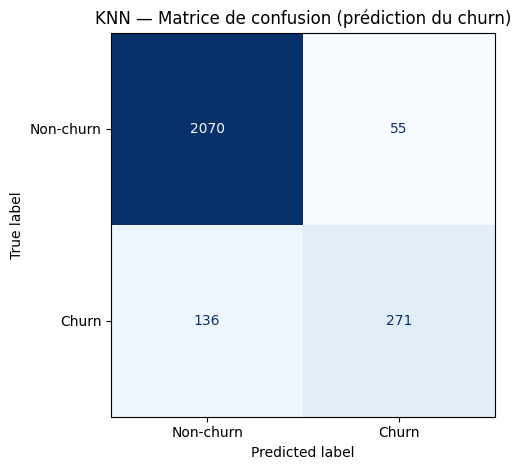

Matrice de confusion sauvegardée : knn_confusion_matrix.png


In [7]:
print("\n" + "=" * 60)
print("ÉTAPE 6 — KNN : PRÉDICTION SUPERVISÉE DU CHURN")
print("=" * 60)

y = df_sample["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")
print(f"Taux de churn train : {y_train.mean() * 100:.1f}% | test : {y_test.mean() * 100:.1f}%")

# Recherche du meilleur k par validation croisée (F1, car classes déséquilibrées)
param_grid = {"n_neighbors": list(range(3, 26, 2)), "weights": ["uniform", "distance"]}
grid = GridSearchCV(
    KNeighborsClassifier(), param_grid, scoring="f1", cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"\nMeilleurs paramètres (CV, score F1) : {grid.best_params_}")
print(f"Score F1 en validation croisée : {grid.best_score_:.3f}")

knn = grid.best_estimator_
y_pred = knn.predict(X_test)

print(f"\nAccuracy (test) : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-score churn (test) : {f1_score(y_test, y_pred):.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Non-churn", "Churn"]))

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Non-churn", "Churn"]).plot(
    cmap="Blues", colorbar=False
)
plt.title("KNN — Matrice de confusion (prédiction du churn)")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=150)
plt.show()
print("Matrice de confusion sauvegardée : knn_confusion_matrix.png")

## Étape 7 — Clustering K-Means par profil dépensier

Segmentation complémentaire, indépendante des segments comportementaux de l'étape 4, basée uniquement sur les variables de dépense et d'utilisation du crédit. Objectif : faire ressortir des profils dépensiers (petit utilisateur, gros dépensier, dépense en hausse/baisse, etc.) et les croiser avec le churn.

ÉTAPE 7 — CLUSTERING K-MEANS PAR PROFIL DÉPENSIER


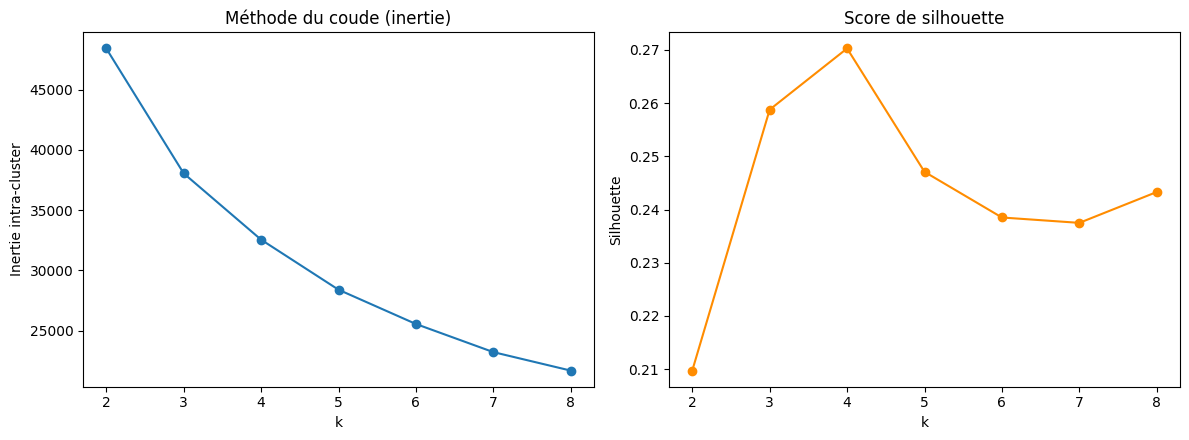


Meilleur k selon le score de silhouette : k = 4 (silhouette = 0.270)


In [8]:
print("=" * 60)
print("ÉTAPE 7 — CLUSTERING K-MEANS PAR PROFIL DÉPENSIER")
print("=" * 60)

# Credit_Limit et Avg_Open_To_Buy sont quasi-identiques (corr = 1.00, cf. étape 2) :
# les garder toutes les deux écraserait le clustering sur ce seul axe de plafond de crédit.
# On ne garde que les variables qui décrivent le comportement de dépense lui-même.
spending_features = [
    "Total_Revolving_Bal",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

X_spend = X_scaled_df[spending_features].values

# Choix de k par méthode du coude + score de silhouette
k_range = range(2, 9)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_spend)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_spend, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie intra-cluster")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("kmeans_choix_k.png", dpi=150)
plt.show()

k_spend = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nMeilleur k selon le score de silhouette : k = {k_spend} (silhouette = {max(silhouettes):.3f})")


Profil moyen (variables de dépense) par cluster K-Means :
                  Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  \
Profil_Depensier                                                               
0                               390.0                   0.7           3371.0   
1                              1422.9                   0.8          12619.3   
2                              1722.0                   0.7           3656.9   
3                              1432.8                   1.1           2474.9   

                  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  Avg_Utilization_Ratio  
Profil_Depensier                                                              
0                           58.6                  0.6                    0.0  
1                          104.2                  0.7                    0.2  
2                           64.6                  0.7                    0.5  
3                           46.6                  1.0            

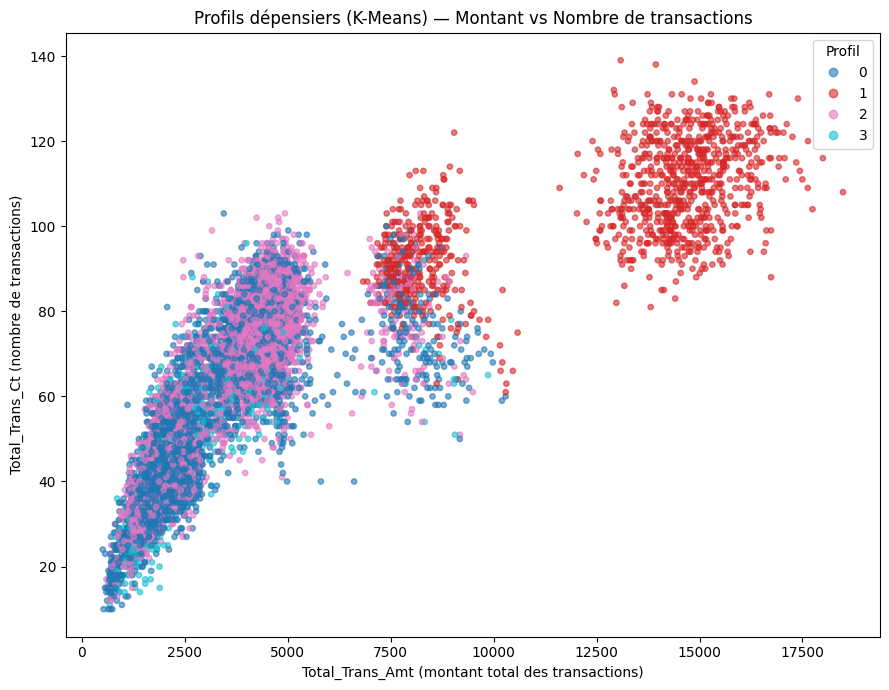

Visualisation sauvegardée : kmeans_profil_depensier.png


In [9]:
kmeans_final = KMeans(n_clusters=k_spend, random_state=RANDOM_STATE, n_init=10)
df_sample["Profil_Depensier"] = kmeans_final.fit_predict(X_spend)

# Profil moyen des variables de dépense par cluster
spend_profile_means = df_sample.groupby("Profil_Depensier")[spending_features].mean().round(1)
print("\nProfil moyen (variables de dépense) par cluster K-Means :")
print(spend_profile_means)

# Taille et taux de churn par profil dépensier
spend_size = df_sample.groupby("Profil_Depensier").size().rename("Nb_clients")
spend_churn = (df_sample.groupby("Profil_Depensier")["Churn"].mean() * 100).round(1).rename("Taux_churn_%")

resultats_kmeans = pd.concat([spend_size, spend_churn, spend_profile_means], axis=1)
resultats_kmeans = resultats_kmeans.sort_values("Taux_churn_%", ascending=False)

print("\n" + "=" * 60)
print("TABLE — PROFILS DÉPENSIERS (K-MEANS) x TAUX DE CHURN")
print("=" * 60)
print(resultats_kmeans)

resultats_kmeans.to_csv("kmeans_profil_depensier_resultats.csv")
print("\nTable exportée : kmeans_profil_depensier_resultats.csv")

# Visualisation : montant total des transactions vs nombre de transactions, coloré par profil
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df_sample["Total_Trans_Amt"],
    df_sample["Total_Trans_Ct"],
    c=df_sample["Profil_Depensier"],
    cmap="tab10",
    alpha=0.6,
    s=15,
)
plt.xlabel("Total_Trans_Amt (montant total des transactions)")
plt.ylabel("Total_Trans_Ct (nombre de transactions)")
plt.title("Profils dépensiers (K-Means) — Montant vs Nombre de transactions")
plt.legend(*scatter.legend_elements(), title="Profil")
plt.tight_layout()
plt.savefig("kmeans_profil_depensier.png", dpi=150)
plt.show()
print("Visualisation sauvegardée : kmeans_profil_depensier.png")